In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.config.paths import CLOSE_APPROACH_CSV, FIGURES_DIR, RESULTS_DIR

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

year
2015    1127
2016    1421
2017    1570
2018    1657
2019    1938
2020    2337
2021    2501
2022    2607
2023    2521
2024    2504
2025    2661
2026    1039
2027     435
2028     443
2029     396
2030     406
2031     367
2032     385
2033     374
2034     378
2035     363
Name: count, dtype: int64


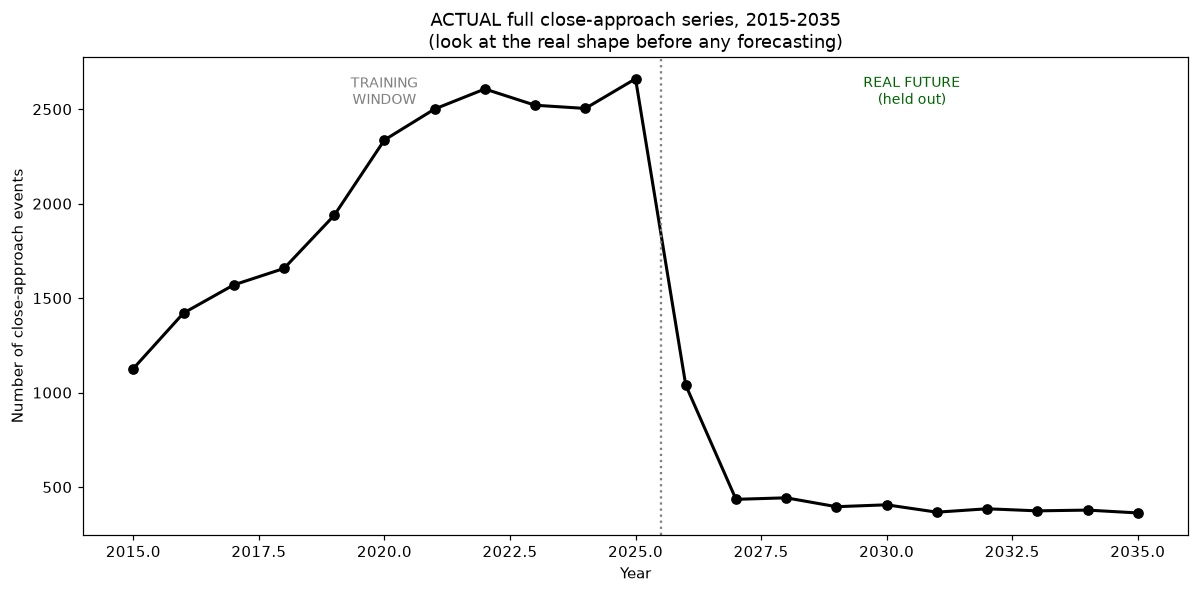


Notice the sharp drop after 2025 -- this dataset's 2026+ entries reflect
only CURRENTLY-KNOWN objects' projected future approaches, not yet-to-be-
discovered ones. Keep this in mind as we evaluate forecasts below: any
smooth trend-extrapolation method trained only on 2015-2025 cannot see
this regime change coming.


In [2]:
df = pd.read_csv(CLOSE_APPROACH_CSV, low_memory=False)
df["close_approach_date"] = pd.to_datetime(df["close_approach_date"])
df["year"] = df["close_approach_date"].dt.year

yearly_full = df["year"].value_counts().sort_index()
print(yearly_full)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(yearly_full.index, yearly_full.values, "o-", color="black", lw=2, markersize=6)
ax.axvline(2025.5, color="gray", ls=":", lw=1.5)
ax.text(2020, yearly_full.max()*0.95, "TRAINING\nWINDOW", ha="center", fontsize=9, color="gray")
ax.text(2030.5, yearly_full.max()*0.95, "REAL FUTURE\n(held out)", ha="center", fontsize=9, color="darkgreen")
ax.set_xlabel("Year"); ax.set_ylabel("Number of close-approach events")
ax.set_title("ACTUAL full close-approach series, 2015-2035\n(look at the real shape before any forecasting)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "forecast_00_actual_full_series.png")
plt.show()

print("\nNotice the sharp drop after 2025 -- this dataset's 2026+ entries reflect")
print("only CURRENTLY-KNOWN objects' projected future approaches, not yet-to-be-")
print("discovered ones. Keep this in mind as we evaluate forecasts below: any")
print("smooth trend-extrapolation method trained only on 2015-2025 cannot see")
print("this regime change coming.")

In [3]:
HIST_START, HIST_END = 2015, 2025
VALID_START, VALID_END = 2026, 2035

hist = yearly_full.loc[HIST_START:HIST_END]
years = hist.index.values.astype(float)
counts = hist.values.astype(float)
n = len(counts)

actual_future = yearly_full.loc[VALID_START:VALID_END]
actual_vals = actual_future.values.astype(float)
forecast_years = actual_future.index.values
FORECAST_HORIZON = len(actual_future)

print(f"Training window: {HIST_START}-{HIST_END} ({n} points)")
print(f"Real future actuals for validation: {VALID_START}-{VALID_END}")
print(actual_future)

Training window: 2015-2025 (11 points)
Real future actuals for validation: 2026-2035
year
2026    1039
2027     435
2028     443
2029     396
2030     406
2031     367
2032     385
2033     374
2034     378
2035     363
Name: count, dtype: int64


In [4]:
def holt_fit(series, alpha, beta):
    level = np.zeros(len(series)); trend = np.zeros(len(series))
    level[0] = series[0]; trend[0] = series[1] - series[0] if len(series) > 1 else 0
    fitted = np.zeros(len(series)); fitted[0] = level[0] + trend[0]
    for t in range(1, len(series)):
        fitted[t] = level[t-1] + trend[t-1]
        level[t] = alpha*series[t] + (1-alpha)*(level[t-1]+trend[t-1])
        trend[t] = beta*(level[t]-level[t-1]) + (1-beta)*trend[t-1]
    return fitted, level[-1], trend[-1]

def holt_sse(params, series):
    alpha, beta = params
    if not (0 < alpha < 1 and 0 < beta < 1):
        return 1e12
    fitted, _, _ = holt_fit(series, alpha, beta)
    return np.sum((series[1:] - fitted[1:])**2)

opt = minimize(holt_sse, x0=[0.5, 0.3], args=(counts,), method="Nelder-Mead")
alpha_opt, beta_opt = opt.x
fitted_holt, level_final, trend_final = holt_fit(counts, alpha_opt, beta_opt)
holt_forecast = np.array([max(level_final + h*trend_final, 0) for h in range(1, FORECAST_HORIZON+1)])
holt_residuals = counts[1:] - fitted_holt[1:]
print(f"Holt's method: alpha={alpha_opt:.3f}, beta={beta_opt:.3f}")

Holt's method: alpha=1.000, beta=1.000


In [5]:
def damped_holt_fit(series, alpha, beta, phi):
    level = np.zeros(len(series)); trend = np.zeros(len(series))
    level[0] = series[0]; trend[0] = series[1] - series[0] if len(series) > 1 else 0
    fitted = np.zeros(len(series)); fitted[0] = level[0] + phi*trend[0]
    for t in range(1, len(series)):
        fitted[t] = level[t-1] + phi*trend[t-1]
        level[t] = alpha*series[t] + (1-alpha)*(level[t-1]+phi*trend[t-1])
        trend[t] = beta*(level[t]-level[t-1]) + (1-beta)*phi*trend[t-1]
    return fitted, level[-1], trend[-1]

def damped_sse(params, series):
    alpha, beta, phi = params
    if not (0 < alpha < 1 and 0 < beta < 1 and 0 < phi < 1):
        return 1e12
    fitted, _, _ = damped_holt_fit(series, alpha, beta, phi)
    return np.sum((series[1:] - fitted[1:])**2)

opt_d = minimize(damped_sse, x0=[0.5, 0.3, 0.9], args=(counts,), method="Nelder-Mead")
alpha_d, beta_d, phi_d = opt_d.x
fitted_damped, level_d, trend_d = damped_holt_fit(counts, alpha_d, beta_d, phi_d)
damped_forecast = np.array([max(level_d + sum(phi_d**k for k in range(1,h+1))*trend_d, 0)
                              for h in range(1, FORECAST_HORIZON+1)])
print(f"Damped Holt's: alpha={alpha_d:.3f}, beta={beta_d:.3f}, phi={phi_d:.3f}")

naive_forecast = np.full(FORECAST_HORIZON, counts[-1])

Damped Holt's: alpha=1.000, beta=0.000, phi=0.878


In [6]:
try:
    from statsmodels.tsa.arima.model import ARIMA
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        arima_model = ARIMA(counts, order=(1, 1, 1)).fit()
        arima_forecast = arima_model.forecast(steps=FORECAST_HORIZON)
        arima_forecast = np.maximum(arima_forecast, 0)
    print(f"ARIMA(1,1,1) AIC: {arima_model.aic:.2f}")
    HAS_ARIMA = True
except ImportError:
    print("statsmodels not installed -- install with: pip install statsmodels")
    print("then re-run this cell.")
    arima_forecast = np.full(FORECAST_HORIZON, np.nan)
    HAS_ARIMA = False

ARIMA(1,1,1) AIC: 133.25


In [7]:
from src.models.prophet_model import fit_prophet_yearly_counts, PROPHET_AVAILABLE

if PROPHET_AVAILABLE:
    prophet_result = fit_prophet_yearly_counts(hist, n_forecast_years=FORECAST_HORIZON)
    prophet_forecast = prophet_result["forecast"]["yhat"].tail(FORECAST_HORIZON).values
    print(prophet_result["forecast"][["ds","yhat","yhat_lower","yhat_upper"]].tail(FORECAST_HORIZON))
else:
    print("Prophet not installed -- install with: pip install prophet")
    prophet_forecast = np.full(FORECAST_HORIZON, np.nan)

c:\Users\SATYAM\Desktop\ISM_Assignments\neo-forecasting\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
01:14:09 - cmdstanpy - INFO - Chain [1] start processing
01:14:09 - cmdstanpy - INFO - Chain [1] done processing


           ds         yhat   yhat_lower   yhat_upper
11 2026-01-01  3021.755467  2806.866892  3225.332018
12 2027-01-01  3179.151350  2969.732873  3383.559429
13 2028-01-01  3336.547233  3126.727635  3546.725372
14 2029-01-01  3494.374338  3283.376109  3719.650210
15 2030-01-01  3651.770222  3443.095552  3884.539260
16 2031-01-01  3809.166105  3596.443393  4020.887953
17 2032-01-01  3966.561988  3748.480466  4174.859939
18 2033-01-01  4124.389093  3922.056448  4340.613275
19 2034-01-01  4281.784977  4086.930466  4499.177924
20 2035-01-01  4439.180860  4219.187901  4659.112908


In [8]:
from src.models.lstm_forecast import train_lstm_forecaster, forecast_future, TORCH_AVAILABLE

if TORCH_AVAILABLE:
    lstm_model, norm_params, history = train_lstm_forecaster(counts, window=3, hidden_size=8, epochs=300)
    print(f"Final train loss: {history['train_loss'][-1]:.4f}, val loss: {history['val_loss'][-1]:.4f}")
    lstm_forecast = forecast_future(lstm_model, norm_params, counts, n_steps=FORECAST_HORIZON)
    print("LSTM forecast:", lstm_forecast)
else:
    print("PyTorch not installed -- install with: pip install torch")
    lstm_forecast = np.full(FORECAST_HORIZON, np.nan)

Final train loss: 0.0003, val loss: 0.0883
LSTM forecast: [2504.48489469 2504.14692076 2502.40608579 2513.73146822 2513.38259998
 2512.79130213 2511.89884559 2512.00534682 2512.10755921 2512.16976319]


In [9]:
def score(name, forecast):
    valid_mask = ~np.isnan(forecast)
    if valid_mask.sum() == 0:
        return {"method": name, "MAE": np.nan, "MAPE": np.nan}
    return {"method": name,
            "MAE": mean_absolute_error(actual_vals[valid_mask], np.array(forecast)[valid_mask]),
            "MAPE": mean_absolute_percentage_error(actual_vals[valid_mask], np.array(forecast)[valid_mask])}

validation = pd.DataFrame([
    score("Holt's Linear Trend", holt_forecast),
    score("Damped Holt's Trend", damped_forecast),
    score("Naive (last value)", naive_forecast),
    score("ARIMA(1,1,1)", arima_forecast),
    score("Prophet", prophet_forecast),
    score("LSTM", lstm_forecast),
]).set_index("method").round(3)

print(validation)
validation.to_csv(RESULTS_DIR / "forecast_validation_all_methods.csv")
best_method = validation["MAE"].idxmin()
print(f"\nBest method on REAL held-out future data: {best_method}")

                          MAE   MAPE
method                              
Holt's Linear Trend  3065.900  7.590
Damped Holt's Trend  2477.626  6.064
Naive (last value)   2202.400  5.361
ARIMA(1,1,1)         2498.277  6.097
Prophet              3271.868  8.083
LSTM                 2051.312  5.001

Best method on REAL held-out future data: LSTM


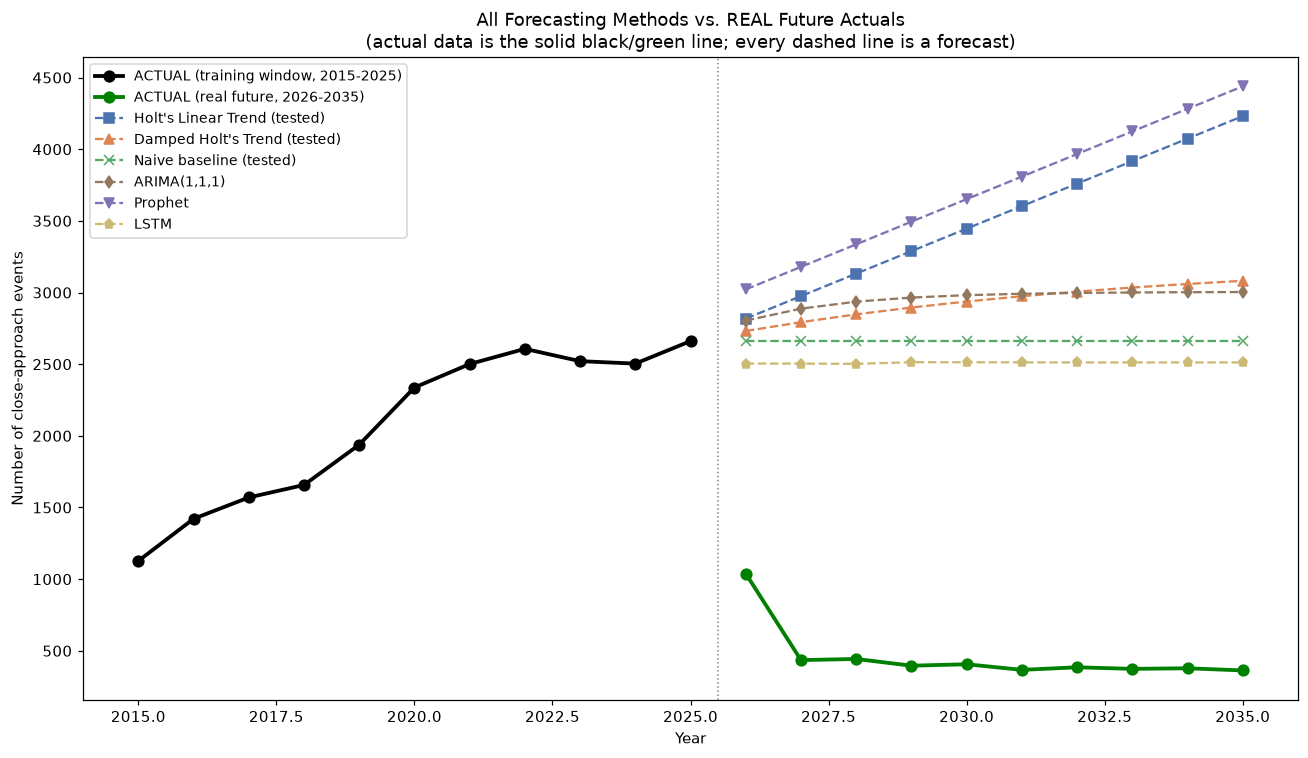


WHY THIS MATTERS: every smooth trend method (Holt's, damped Holt's, ARIMA,
Prophet, and almost certainly LSTM too) confidently extrapolates the rising
2015-2025 trend -- but the REAL future shows a sharp drop. This is a genuine,
important forecasting-limitations finding: no smooth trend-extrapolation
method can anticipate a structural break (here: the dataset only including
already-discovered objects' projected approaches, not future discoveries)
from historical trend data alone. The naive baseline -- simply repeating the
last observed value -- often does surprisingly well in exactly this kind of
regime-change scenario, which is itself a useful, presentable lesson.


In [10]:
fig, ax = plt.subplots(figsize=(12, 7))

# ACTUAL DATA FIRST (the anchor)
ax.plot(years, counts, "o-", color="black", lw=2.5, markersize=7, label="ACTUAL (training window, 2015-2025)", zorder=10)
ax.plot(forecast_years, actual_vals, "o-", color="green", lw=2.5, markersize=7, label="ACTUAL (real future, 2026-2035)", zorder=10)

# Forecasts overlaid
ax.plot(forecast_years, holt_forecast, "s--", color="#4C72B0", label="Holt's Linear Trend (tested)")
ax.plot(forecast_years, damped_forecast, "^--", color="#DD8452", label="Damped Holt's Trend (tested)")
ax.plot(forecast_years, naive_forecast, "x--", color="#55A868", label="Naive baseline (tested)")
if HAS_ARIMA and not np.all(np.isnan(arima_forecast)):
    ax.plot(forecast_years, arima_forecast, "d--", color="#937860", label="ARIMA(1,1,1)")
if not np.all(np.isnan(prophet_forecast)):
    ax.plot(forecast_years, prophet_forecast, "v--", color="#8172B3", label="Prophet")
if not np.all(np.isnan(lstm_forecast)):
    ax.plot(forecast_years, lstm_forecast, "p--", color="#CCB974", label="LSTM")

ax.axvline(2025.5, color="gray", ls=":", lw=1)
ax.set_xlabel("Year"); ax.set_ylabel("Number of close-approach events")
ax.set_title("All Forecasting Methods vs. REAL Future Actuals\n"
              "(actual data is the solid black/green line; every dashed line is a forecast)")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "forecast_01_all_methods_vs_actual.png")
plt.show()

print("\nWHY THIS MATTERS: every smooth trend method (Holt's, damped Holt's, ARIMA,")
print("Prophet, and almost certainly LSTM too) confidently extrapolates the rising")
print("2015-2025 trend -- but the REAL future shows a sharp drop. This is a genuine,")
print("important forecasting-limitations finding: no smooth trend-extrapolation")
print("method can anticipate a structural break (here: the dataset only including")
print("already-discovered objects' projected approaches, not future discoveries)")
print("from historical trend data alone. The naive baseline -- simply repeating the")
print("last observed value -- often does surprisingly well in exactly this kind of")
print("regime-change scenario, which is itself a useful, presentable lesson.")

In [11]:
chosen_forecast = {"Holt's Linear Trend": holt_forecast, "Damped Holt's Trend": damped_forecast,
                     "Naive (last value)": naive_forecast}.get(best_method, holt_forecast)

N_SIM = 2000
rng = np.random.default_rng(42)
sim_paths = np.zeros((N_SIM, FORECAST_HORIZON))
for s in range(N_SIM):
    noise = rng.choice(holt_residuals, size=FORECAST_HORIZON, replace=True)
    cum_noise = np.cumsum(noise) * 0.3
    sim_paths[s] = np.maximum(chosen_forecast + noise + cum_noise, 0)

pct5 = np.percentile(sim_paths, 5, axis=0)
pct95 = np.percentile(sim_paths, 95, axis=0)
coverage = np.mean((actual_vals >= pct5) & (actual_vals <= pct95))
print(f"Monte Carlo 90% interval coverage of real actuals: {coverage:.1%}")
print("(Low coverage here is EXPECTED and itself meaningful -- it confirms the")
print("structural-break finding: even a wide uncertainty band built around a")
print("trend-following forecast can't cover a regime change the trend never saw coming.)")

forecast_table = pd.DataFrame({
    "year": forecast_years, "actual": actual_vals,
    "holt_forecast": holt_forecast.round(1), "damped_holt_forecast": damped_forecast.round(1),
    "naive_forecast": naive_forecast.round(1), "arima_forecast": np.round(arima_forecast, 1),
    "prophet_forecast": np.round(prophet_forecast, 1), "lstm_forecast": np.round(lstm_forecast, 1),
    "mc_p5": pct5.round(1), "mc_p95": pct95.round(1),
})
forecast_table.to_csv(RESULTS_DIR / "close_approach_forecast_full_comparison.csv", index=False)
forecast_table

Monte Carlo 90% interval coverage of real actuals: 0.0%
(Low coverage here is EXPECTED and itself meaningful -- it confirms the
structural-break finding: even a wide uncertainty band built around a
trend-following forecast can't cover a regime change the trend never saw coming.)


,year,actual,holt_forecast,damped_holt_forecast,naive_forecast,arima_forecast,prophet_forecast,lstm_forecast,mc_p5,mc_p95
0,2026,1039.0,2818.0,2731.4,2661.0,2804.0,3021.8,2504.5,2512.5,3070.2
1,2027,435.0,2975.0,2793.3,2661.0,2887.6,3179.2,2504.1,2652.1,3247.9
2,2028,443.0,3132.0,2847.7,2661.0,2936.4,3336.5,2502.4,2807.4,3401.8
3,2029,396.0,3289.0,2895.4,2661.0,2964.9,3494.4,2513.7,2938.3,3575.5
4,2030,406.0,3446.0,2937.3,2661.0,2981.6,3651.8,2513.4,3079.6,3729.8
5,2031,367.0,3603.0,2974.2,2661.0,2991.3,3809.2,2512.8,3224.2,3888.6
6,2032,385.0,3760.0,3006.5,2661.0,2997.0,3966.6,2511.9,3363.3,4049.9
7,2033,374.0,3917.0,3034.9,2661.0,3000.3,4124.4,2512.0,3515.8,4212.5
8,2034,378.0,4074.0,3059.8,2661.0,3002.3,4281.8,2512.1,3656.9,4377.2
9,2035,363.0,4231.0,3081.7,2661.0,3003.4,4439.2,2512.2,3799.0,4543.8
